# Accelerating star

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import KeplerModel

In [3]:
np.random.seed(42)

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. In the future, we can either retrieve the data from the archive. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3. In this example, we will simulate DR4 epoch astrometry for the star [HD 135344 A](https://en.wikipedia.org/wiki/HD_135344).

In [4]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


In [6]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In this next example, we will simulate epoch astrometry for a 30 $M_\mathrm{J}$ companion on a 5 au orbit, which causes a detectable acceleration of the star's proper motion. 

In [7]:
mass_1 = primary_mass[0]  # (Msun)
mass_2 = 0.05  # (Msun)

In [8]:
sma, ecc, inc, aop, pan, tau = 7., 0.0, np.radians(30.0), np.radians(0.0), np.radians(90.0), 0.5

In [9]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.05
   - Relative semi-major axis (au) = 7.00
   - Eccentricity = 0.00
   - Inclination (deg) = 30.00
   - Argument of periastron (deg) = 0.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50
   - Period (days) = 4509.68
   - Semi-major axis of photocenter (mas) = 1.15


Let's plot the stellar orbit in comparison with the simulated 1D epoch astrometry.

In [10]:
kepler_model = KeplerModel(epoch_astrometry=epoch_astrom)


-------------------
Calculate residuals
-------------------


---------------------
Calculate orbit model
---------------------

Stellar parameters:
   - RA (deg) = 0.000
   - Dec (deg) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008

Orbit parameters:
   - Period (days) = 4509.683
   - Eccentricity = 0.000
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 1.153
   - Inclination (deg) = 30.000
   - Argument of periastron (deg) = 0.000
   - PA of ascending node (deg) = 90.000

Reduced chi^2 = 1.14
RUWE = 1.07

----------
Plot orbit
----------



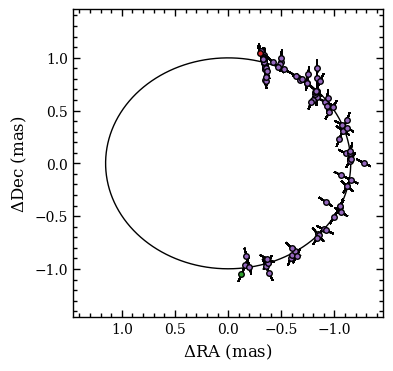

In [11]:
fig = kepler_model.plot_orbit(model_param=model_param, plot_file='plot.png')

In [12]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Binary star (7 parameters)
--------------------------

Reduced chi^2 = 1.936
RUWE = 1.391
F2 estimator = 5.008
Inflation factor = 1.397
Significance dmu/dt = 14.987

Best-fit parameters:
   - RA offset = -1.129 +/- 0.025 mas
   - Dec offset = 0.039 +/- 0.019 mas
   - Parallax = 7.410 +/- 0.020 mas
   - mu in RA = -18.743 +/- 0.011 mas/yr
   - mu in Dec = -23.612 +/- 0.006 mas/yr
   - dmu/dt in RA = 0.249 +/- 0.017 mas/yr^2
   - dmu/dt in Dec = -0.013 +/- 0.008 mas/yr^2


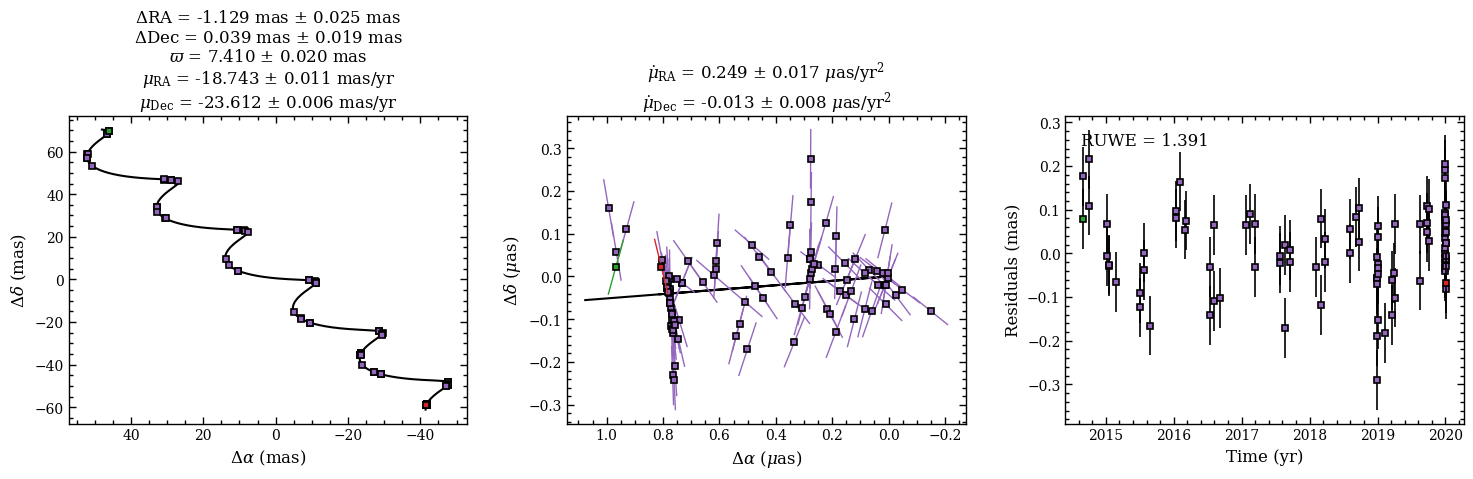

In [13]:
results = leastsq.accel_7param(plot_file='plot.png')

The RUWE is 1.4 when including the acceleration and the significance on $\frac{d \mu}{dt}$ is high. Let's check if the data also warrants including the acceleration derivative, so the second-order derivative of the proper motion.


--------------------------
Binary star (9 parameters)
--------------------------

Reduced chi^2 = 1.071
RUWE = 1.035
F2 estimator = 0.512
Inflation factor = 1.039
Significance dmu/dt = 17.924
Significance d^2mu/d^2t = 8.775

Best-fit parameters:
   - RA offset = -1.128 +/- 0.022 mas
   - Dec offset = -0.004 +/- 0.017 mas
   - Parallax = 7.423 +/- 0.017 mas
   - mu in RA = -18.750 +/- 0.024 mas/yr
   - mu in Dec = -23.488 +/- 0.015 mas/yr
   - dmu/dt in RA = 0.267 +/- 0.015 mas/yr^2
   - dmu/dt in Dec = -0.003 +/- 0.008 mas/yr^2
   - d^2mu/d^2t in RA = 0.014 +/- 0.033 mas/yr^3
   - d^2mu/d^2t in Dec = -0.135 +/- 0.015 mas/yr^3


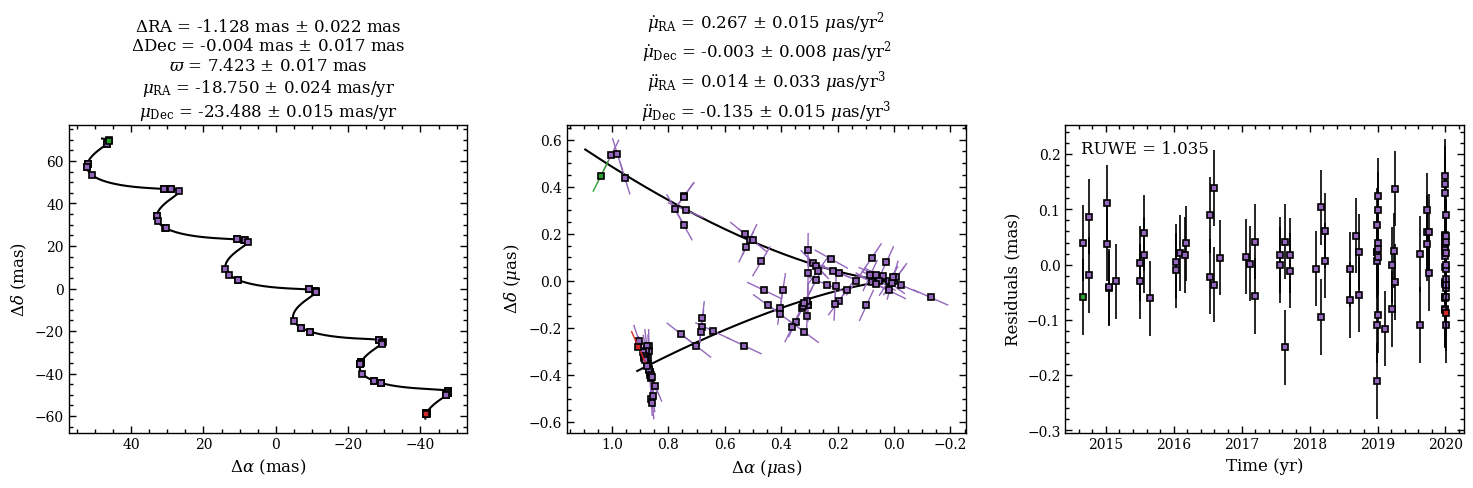

In [14]:
results = leastsq.accel_9param(plot_file='res_9param.png')

The RUWE decreased to 1.0 and the second-order proper motion derivative is quite well constrained.